In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('..')

In [3]:
from articulate_anything.utils.metric import compute_link_placement_result, analyze_link_placement_by_type, compute_joint_pred_result, analyze_joint_pred_by_type

/home/link/miniconda3/envs/articulate-anything-clean/lib/python3.9/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
pybullet build time: Nov 28 2023 23:52:03


In [4]:
result_dir = "results"
dataset_dir = "datasets/partnet-mobility-v0/dataset"
strategy="gt"

In [5]:
link_diffs = compute_link_placement_result(result_dir, strategy=strategy, dataset_dir=dataset_dir)
type_results = analyze_link_placement_by_type(link_diffs)

In [6]:
type_results

defaultdict(dict,
            {'Faucet': {'avg_diff': 0.01434614688903099,
              'count': 4,
              'success_dicts': {'1028': True,
               '1034': True,
               '1668': True,
               '2083': True},
              'success_rate': 1.0,
              'num_failures': 0},
             'Display': {'avg_diff': 0.15066520137875022,
              'count': 5,
              'success_dicts': {'3392': False,
               '4541': False,
               '4555': False,
               '4628': False,
               '5050': True},
              'success_rate': 0.2,
              'num_failures': 4},
             'Bottle': {'avg_diff': 0.021964398675093755,
              'count': 3,
              'success_dicts': {'3830': True, '4314': True, '5850': True},
              'success_rate': 1.0,
              'num_failures': 0},
             'Clock': {'avg_diff': 9.25185853854297e-18,
              'count': 1,
              'success_dicts': {'7037': True},
              'suc

In [7]:
joint_diffs = compute_joint_pred_result(result_dir, strategy=strategy, dataset_dir=dataset_dir, use_result_dir=False)
joint_results = analyze_joint_pred_by_type(joint_diffs)

In [8]:
import random
from articulate_anything.utils.partnet_utils import track_obj_types, sample_obj_id
from collections import Counter

def filter_objects_by_link_diff(link_diffs, threshold=0.05):
    return [obj_id for obj_id, data in link_diffs.items() if data['link_diff']['average_diff'] < threshold]

def sample_proportional_to_category_size_filtered(real2code_categories, num_samples, filtered_obj_ids):
    obj_types = track_obj_types()
    
    # Filter obj_types to only include objects in filtered_obj_ids
    filtered_obj_types = {cat: [obj for obj in objs if obj in filtered_obj_ids] 
                          for cat, objs in obj_types.items()}
    
    total_objects = sum(len(filtered_obj_types[cat]) for cat in real2code_categories if cat in filtered_obj_types)
    
    if total_objects == 0:
        raise ValueError("No objects meet the filtering criteria")
    
    sampled_objects = []
    for category in real2code_categories:
        if category in filtered_obj_types:
            proportion = len(filtered_obj_types[category]) / total_objects
            num_category_samples = int(num_samples * proportion)
            category_samples = random.sample(filtered_obj_types[category], 
                                             min(num_category_samples, len(filtered_obj_types[category])))
            sampled_objects.extend(category_samples)
    
    # Add any remaining samples due to rounding
    while len(sampled_objects) < num_samples:
        category = random.choice([cat for cat in real2code_categories if cat in filtered_obj_types])
        remaining_objects = [obj for obj in filtered_obj_types[category] if obj not in sampled_objects]
        if remaining_objects:
            extra_sample = random.choice(remaining_objects)
            sampled_objects.append(extra_sample)
        else:
            break  # Break if we've exhausted all available objects
    
    return sampled_objects

def train_val_split_filtered(real2code_categories, num_trains, num_vals, link_diffs):
    total_samples = num_trains + num_vals
    
    # Filter objects based on link difference
    filtered_obj_ids = filter_objects_by_link_diff(link_diffs)
    
    # Sample all objects at once
    all_samples = sample_proportional_to_category_size_filtered(real2code_categories, total_samples, filtered_obj_ids)
    
    # Shuffle the samples
    random.shuffle(all_samples)
    
    # Split into train and val sets
    train_samples = all_samples[:num_trains]
    val_samples = all_samples[num_trains:]
    
    return train_samples, val_samples

def print_category_distribution(obj_ids, real2code_categories, set_name):
    category_counts = Counter()
    obj_types = track_obj_types()
    for obj_id in obj_ids:
        for category in real2code_categories:
            if obj_id in obj_types.get(category, []):
                category_counts[category] += 1
                break
        else:
            category_counts['Other'] += 1
    
    total_objects = len(obj_ids)
    print(f"Distribution of objects per category ({set_name} set):")
    print("-------------------------------------")
    for category in real2code_categories:
        count = category_counts[category]
        percentage = (count / total_objects) * 100 if total_objects > 0 else 0
        print(f"{category}: {count} ({percentage:.2f}%)")
    if category_counts['Other'] > 0:
        other_count = category_counts['Other']
        other_percentage = (other_count / total_objects) * 100 if total_objects > 0 else 0
        print(f"Other: {other_count} ({other_percentage:.2f}%)")
    print(f"Total: {total_objects}")

# Usage
real2code_categories = ["StorageFurniture", "Laptop", "Box", "Table", "Refrigerator"]
num_trains = 467
num_vals = 35

# Assuming link_diffs is already computed
train_obj_ids, val_obj_ids = train_val_split_filtered(real2code_categories, num_trains, num_vals, link_diffs)

print_category_distribution(train_obj_ids, real2code_categories, "Training")
print("\n")
print_category_distribution(val_obj_ids, real2code_categories, "Validation")

Distribution of objects per category (Training set):
-------------------------------------
StorageFurniture: 11 (28.21%)
Laptop: 3 (7.69%)
Box: 19 (48.72%)
Table: 4 (10.26%)
Refrigerator: 2 (5.13%)
Total: 39


Distribution of objects per category (Validation set):
-------------------------------------
StorageFurniture: 0 (0.00%)
Laptop: 0 (0.00%)
Box: 0 (0.00%)
Table: 0 (0.00%)
Refrigerator: 0 (0.00%)
Total: 0


In [9]:
def generate_tasks_from_joint_diffs(joint_diffs, sample_set):
    tasks = []
    for key, value in joint_diffs.items():
        obj_id, joint_id, semantic_joint_id = key
        if obj_id in sample_set and value["failure_reason"] == "success":
            task = {
                "obj_id": obj_id,
                "joint_id": joint_id,
                "semantic_joint_id": semantic_joint_id,
                "joint_diff": value,
                "link_diff": link_diffs[obj_id],
            }
            tasks.append(task)
    return tasks

In [10]:
train_tasks = generate_tasks_from_joint_diffs(joint_diffs, train_obj_ids)
val_tasks = generate_tasks_from_joint_diffs(joint_diffs, val_obj_ids)
len(train_tasks), len(val_tasks)

(41, 0)

In [11]:
from articulate_anything.utils.utils import save_json
save_json(train_tasks, "train_tasks.json")
save_json(val_tasks, "val_tasks.json")

In [12]:
# Display results nicely
from articulate_anything.utils.metric import (
    print_link_placement_results, 
    print_joint_prediction_results,
    analyze_failure_types,
    generate_link_placement_latex_table,
    generate_joint_prediction_latex_table, 
    comprehensive_results_summary
)

# Print formatted results
print_link_placement_results(type_results)


Link Placement Success Rate by Object Categories
Category        Count    Success Rate Avg Diff   Failures  
-----------------------------------------------------------------
Remote          41       100.0%       0.0022     0         
Window          37       100.0%       0.0000     0         
Oven            17       100.0%       0.0108     0         
StorageFurniture 11       100.0%       0.0006     0         
Phone           5        100.0%       0.0082     0         
Faucet          4        100.0%       0.0143     0         
Bottle          3        100.0%       0.0220     0         
Laptop          3        100.0%       0.0089     0         
Refrigerator    2        100.0%       0.0076     0         
Scissors        2        100.0%       0.0000     0         
Printer         2        100.0%       0.0000     0         
Clock           1        100.0%       0.0000     0         
Microwave       1        100.0%       0.0014     0         
Dishwasher      1        100.0%       0.004

In [13]:
print_joint_prediction_results(joint_results)


Joint Prediction Results

Microwave:
----------
Joint Type   Count    Success Rate
-----------------------------------
total        19       100.0%      
prismatic    18       100.0%      
revolute     1        100.0%      

Lamp:
-----
Joint Type   Count    Success Rate
-----------------------------------
revolute     2        100.0%      
total        2        100.0%      

Dishwasher:
-----------
Joint Type   Count    Success Rate
-----------------------------------
revolute     1        100.0%      
total        1        100.0%      

StorageFurniture:
-----------------
Joint Type   Count    Success Rate
-----------------------------------
prismatic    17       100.0%      
total        27       88.9%       
revolute     10       70.0%       

Table:
------
Joint Type   Count    Success Rate
-----------------------------------
prismatic    10       100.0%      
total        14       85.7%       
revolute     4        50.0%       

WashingMachine:
---------------
Joint Type   Count

In [14]:
# Analyze failure patterns
analyze_failure_types(joint_diffs, by_category=True)


Failure Analysis by Category
Failure Types:
- success: Joint prediction succeeded
- no_ground_truth: Could not load ground truth joints
- joint_not_in_gt: Joint not found in ground truth
- no_predicted_joints: Could not find predicted joint files
- joint_name_mismatch: Could not match joint names
- joint_diff_computation_failed: Joint comparison failed
- joint_type/joint_axis/joint_origin/joint_limit: Specific joint prediction errors
- vlm_failure: VLM wrote incompilable code (legacy)
- no_valid_result: Other unclassified failures (legacy)


Faucet:
-------
  joint_axis                1      (20.0%)
  joint_origin              3      (60.0%)
  success                   1      (20.0%)

Display:
--------
  joint_axis                2      (33.3%)
  joint_origin              2      (33.3%)
  joint_type                1      (16.7%)
  success                   1      (16.7%)

Oven:
-----
  joint_axis                39     (79.6%)
  joint_type                1      (2.0%)
  success        

In [15]:

# Generate comprehensive summary with LaTeX output
# comprehensive_results_summary(type_results, joint_results, joint_diffs, save_latex=False)

In [16]:
# Or generate individual LaTeX tables
link_latex = generate_link_placement_latex_table(type_results)
joint_latex = generate_joint_prediction_latex_table(joint_results)
print("Link Placement LaTeX:")
print(link_latex)

Link Placement LaTeX:
\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\toprule
Category & Count & Success Rate & Avg Diff & Failures \\
\midrule
Remote & 41 & 100.0\% & 0.0022 & 0 \\
Window & 37 & 100.0\% & 0.0000 & 0 \\
Oven & 17 & 100.0\% & 0.0108 & 0 \\
StorageFurniture & 11 & 100.0\% & 0.0006 & 0 \\
Phone & 5 & 100.0\% & 0.0082 & 0 \\
Faucet & 4 & 100.0\% & 0.0143 & 0 \\
Bottle & 3 & 100.0\% & 0.0220 & 0 \\
Laptop & 3 & 100.0\% & 0.0089 & 0 \\
Refrigerator & 2 & 100.0\% & 0.0076 & 0 \\
Scissors & 2 & 100.0\% & 0.0000 & 0 \\
Printer & 2 & 100.0\% & 0.0000 & 0 \\
Clock & 1 & 100.0\% & 0.0000 & 0 \\
Microwave & 1 & 100.0\% & 0.0014 & 0 \\
Dishwasher & 1 & 100.0\% & 0.0047 & 0 \\
Toaster & 1 & 100.0\% & 0.0317 & 0 \\
KitchenPot & 22 & 95.5\% & 0.0170 & 1 \\
Box & 20 & 95.0\% & 0.0128 & 1 \\
Eyeglasses & 57 & 94.7\% & 0.0202 & 3 \\
Suitcase & 18 & 94.4\% & 0.0183 & 1 \\
Globe & 53 & 94.3\% & 0.0131 & 3 \\
Bucket & 34 & 94.1\% & 0.0075 & 2 \\
Mouse & 13 & 92.3\% & 0.0157 & 1 \\
Pen & 

In [17]:
print(joint_latex)

\begin{table}[h]
\centering
\begin{tabular}{llcc}
\toprule
Category & Joint Type & Count & Success Rate \\
\midrule
Microwave & total & 19 & 100.0\% \\
 & prismatic & 18 & 100.0\% \\
 & revolute & 1 & 100.0\% \\
Lamp & revolute & 2 & 100.0\% \\
 & total & 2 & 100.0\% \\
Dishwasher & revolute & 1 & 100.0\% \\
 & total & 1 & 100.0\% \\
StorageFurniture & prismatic & 17 & 100.0\% \\
 & total & 27 & 88.9\% \\
 & revolute & 10 & 70.0\% \\
Table & prismatic & 10 & 100.0\% \\
 & total & 14 & 85.7\% \\
 & revolute & 4 & 50.0\% \\
WashingMachine & revolute & 8 & 62.5\% \\
 & total & 39 & 51.3\% \\
 & prismatic & 31 & 48.4\% \\
Phone & revolute & 2 & 100.0\% \\
 & total & 93 & 41.9\% \\
 & prismatic & 91 & 40.7\% \\
Chair & revolute & 2 & 50.0\% \\
 & total & 7 & 28.6\% \\
 & prismatic & 5 & 20.0\% \\
Faucet & revolute & 5 & 20.0\% \\
 & total & 5 & 20.0\% \\
Display & revolute & 3 & 33.3\% \\
 & total & 6 & 16.7\% \\
 & prismatic & 3 & 0.0\% \\
Box & revolute & 43 & 16.3\% \\
 & total & 43 & 16

In [18]:
# Add this after computing joint_diffs
from articulate_anything.utils.metric import analyze_no_valid_results

# Analyze the failing cases
failing_joints = analyze_no_valid_results(joint_diffs, result_dir, strategy=strategy, debug_sample_size=3)

print(f"\nTotal joints analyzed: {len(joint_diffs)}")
print(f"Joints with no_valid_result: {len(failing_joints)}")
print(f"Success rate: {(len(joint_diffs) - len(failing_joints)) / len(joint_diffs) * 100:.1f}%")

Found 0 joints with no_valid_result

Total joints analyzed: 2669
Joints with no_valid_result: 0
Success rate: 100.0%


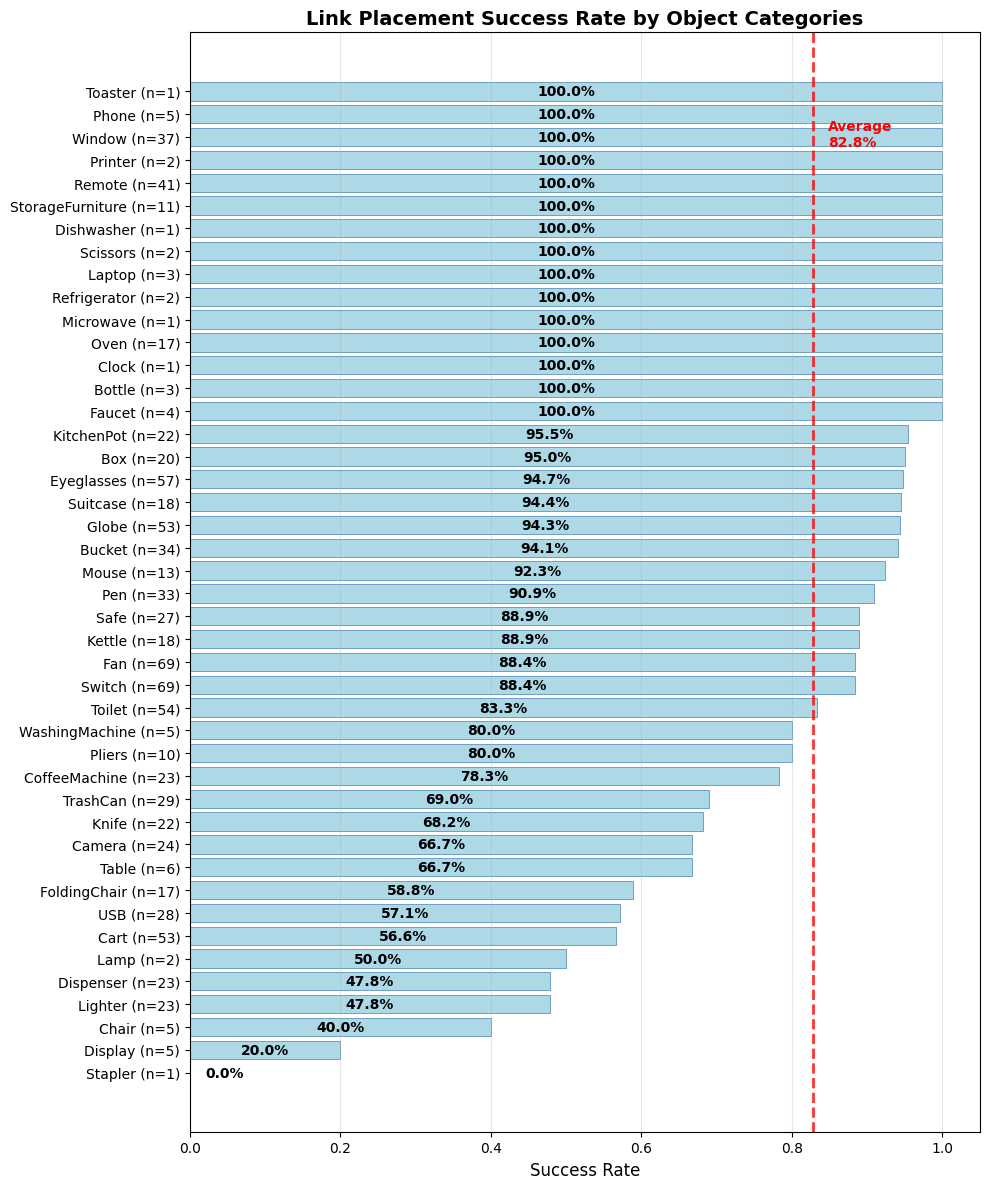

In [19]:
# Import matplotlib if not already imported
import matplotlib.pyplot as plt
from articulate_anything.utils.metric import (
    plot_link_placement_results,
    plot_joint_prediction_results,
    plot_joint_prediction_by_type)

# Create plots for link placement results
fig_link = plot_link_placement_results(type_results, save_path="/home/link/DreMa/third_party/articulate-anything/eval/link_placement_success_rates.png")
plt.show()
# plt.savefig("/home/link/DreMa/third_party/articulate-anything/eval/link_placement_success_rates.png", dpi=300)

# Create plots for joint prediction results (revolute joints only)
# fig_joint_rev = plot_joint_prediction_results(joint_results, 
#                                              title="Revolute Joint Prediction Success Rate by Object Categories",
#                                              joint_type_filter='revolute',
#                                              save_path="revolute_joint_success_rates.png")
# plt.show()

# # Create plots for joint prediction results (prismatic joints only)
# fig_joint_pris = plot_joint_prediction_results(joint_results,
#                                               title="Prismatic Joint Prediction Success Rate by Object Categories", 
#                                               joint_type_filter='prismatic',
#                                               save_path="prismatic_joint_success_rates.png")
# plt.show()

# # Create grouped bar chart showing all joint types
# fig_joint_grouped = plot_joint_prediction_by_type(joint_results, save_path="joint_prediction_by_type.png")
# plt.show()

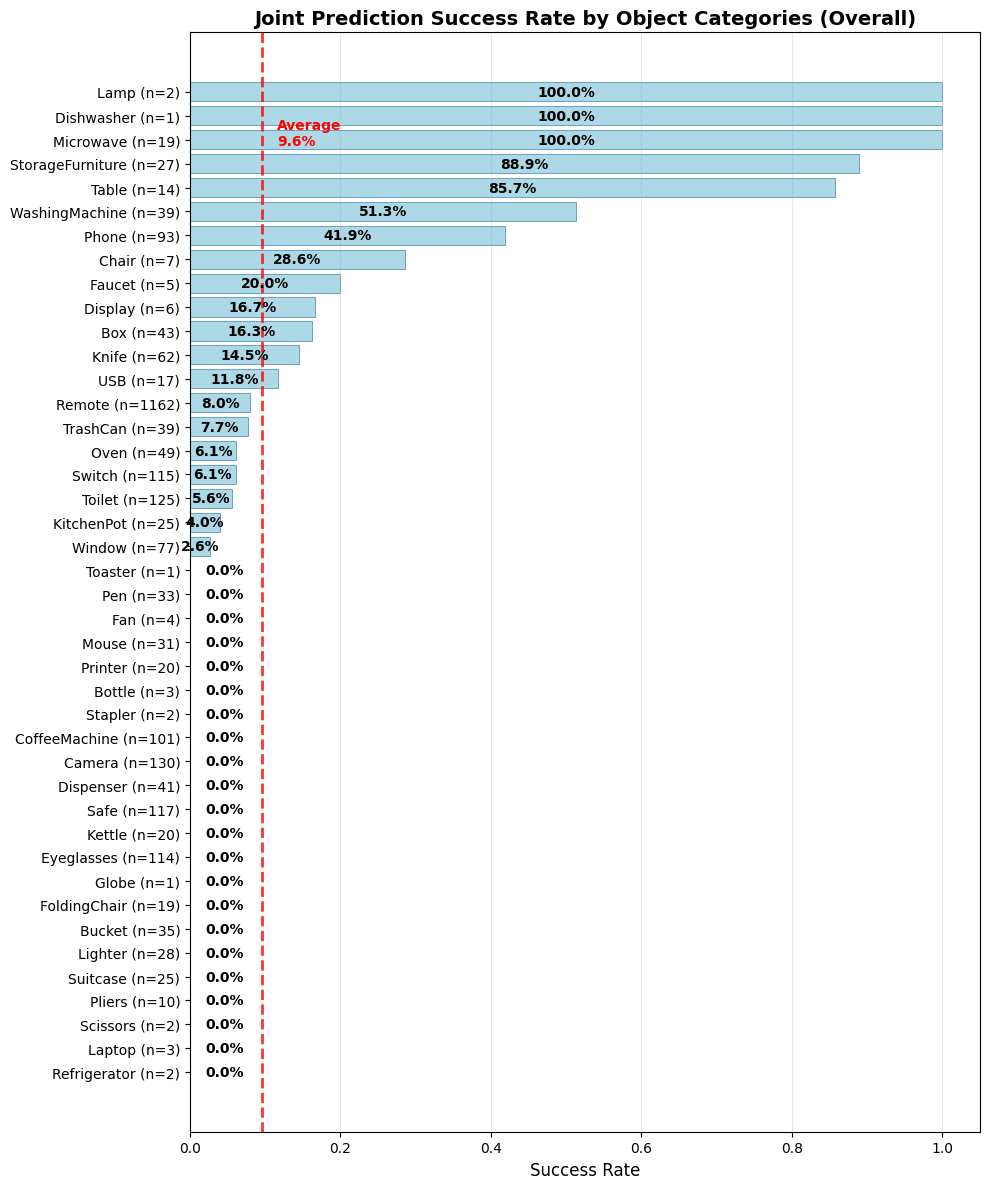

In [20]:
# Create plots for joint prediction results (overall)
fig_joint = plot_joint_prediction_results(joint_results, save_path="/home/link/DreMa/third_party/articulate-anything/eval/joint_prediction_success_rates.png")
plt.show()

Attempting to save pie chart to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie.png
Pie chart saved successfully to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie.png
Verified: File exists at /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie.png


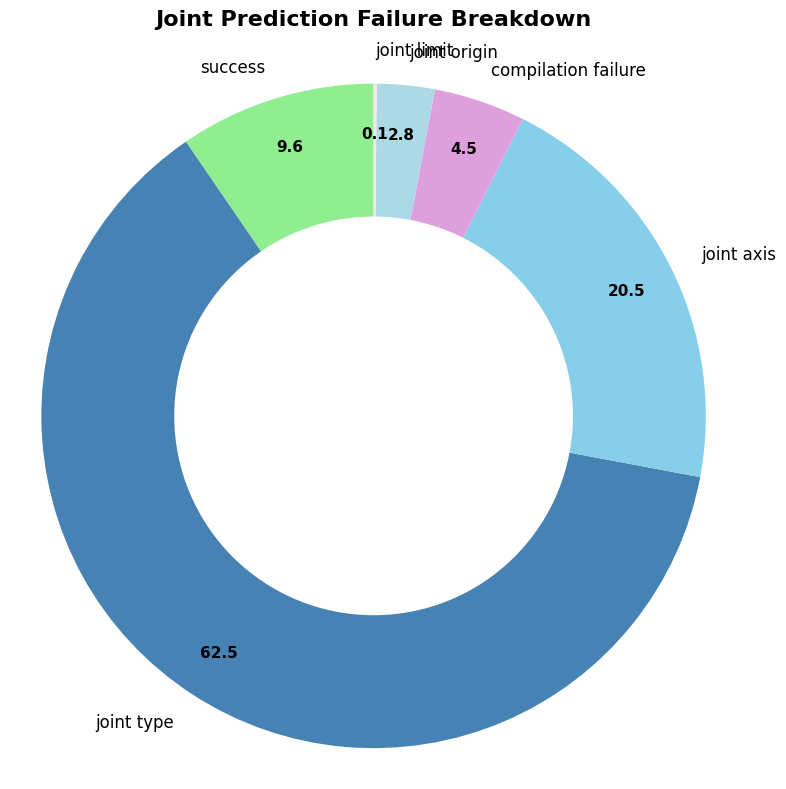

In [21]:
from articulate_anything.utils.metric import (
    plot_failure_breakdown_pie,
    plot_failure_comparison_pie
)

# Create failure breakdown pie chart
fig_pie = plot_failure_breakdown_pie(
    joint_diffs, 
    title="Joint Prediction Failure Breakdown",
    save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie.png"
)
plt.show()

# If you have results from multiple methods to compare:
# fig_comparison = plot_failure_comparison_pie(
#     [joint_diffs_method1, joint_diffs_method2], 
#     ["Method 1", "Method 2"],
#     save_path="failure_comparison_pie.png"
# )
# plt.show()

Attempting to save segmented bar chart to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_bar.png
Segmented bar chart saved successfully to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_bar.png


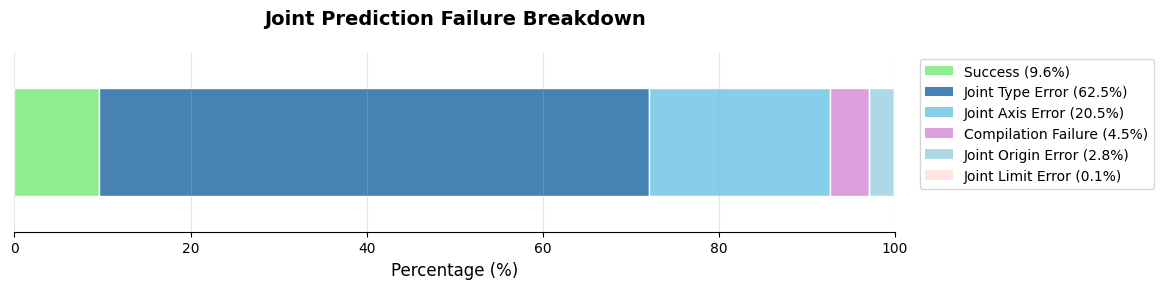

In [22]:
from collections import defaultdict

def plot_failure_breakdown_bar(joint_diffs, title="Joint Prediction Failure Breakdown", 
                                        figsize=(12, 3), save_path=None, method_name="",
                                        show_labels=True, show_percentages=True):
    """
    Create a segmented horizontal bar chart showing the breakdown of failure types.
    Like a pie chart "unrolled" into a single horizontal bar.
    
    Args:
        joint_diffs: Output from compute_joint_pred_result()
        title: Plot title
        figsize: Figure size (width, height)
        save_path: Path to save the plot (if None, plot is not saved)
        method_name: Method name to include in title
        show_labels: Whether to show labels on segments
        show_percentages: Whether to show percentages on segments
    
    Returns:
        matplotlib.figure.Figure: The generated figure
    """
    # Count failure reasons
    failure_counts = defaultdict(int)
    for result in joint_diffs.values():
        failure_reason = result['failure_reason']
        failure_counts[failure_reason] += 1
    
    total_joints = sum(failure_counts.values())
    
    # Define colors for different failure types (same as pie chart)
    color_map = {
        'success': '#90EE90',  # Light green
        'incorrect link placement': '#FFB6C1',  # Light pink/red
        'link_placement_failure': '#FFB6C1',  # Light pink/red (alternative name)
        'joint_origin': '#ADD8E6',  # Light blue
        'joint_axis': '#87CEEB',  # Sky blue
        'joint_type': '#4682B4',  # Steel blue
        'joint_limit': '#FFE4E1',  # Misty rose
        'vlm_failure': '#DDA0DD',  # Plum
        'no_valid_result': '#D3D3D3',  # Light gray
        'no_iterations': '#D3D3D3',  # Light gray
        'no_ground_truth': '#FFA07A',  # Light salmon
        'joint_not_in_gt': '#F0E68C',  # Khaki
        'no_predicted_joints': '#DEB887',  # Burlywood
        'joint_name_mismatch': '#D8BFD8',  # Thistle
        'joint_diff_computation_failed': '#B0C4DE',  # Light steel blue
    }
    
    # Prepare data for segmented bar
    labels = []
    percentages = []
    colors = []
    
    # Sort by size (largest first) but keep success first if it exists
    sorted_failures = sorted(failure_counts.items(), key=lambda x: x[1], reverse=True)
    if 'success' in failure_counts:
        # Move success to the front
        sorted_failures = [item for item in sorted_failures if item[0] != 'success']
        sorted_failures.insert(0, ('success', failure_counts['success']))
    
    for failure_type, count in sorted_failures:
        percentage = (count / total_joints) * 100
        
        # Map failure types to more readable labels
        label_map = {
            'success': 'Success',
            'link_placement_failure': 'Incorrect Link Placement',
            'vlm_failure': 'Compilation Failure',
            'joint_origin': 'Joint Origin Error',
            'joint_axis': 'Joint Axis Error',
            'joint_type': 'Joint Type Error',
            'joint_limit': 'Joint Limit Error',
            'no_valid_result': 'Other Failures',
            'no_iterations': 'No Iterations',
            'no_ground_truth': 'No Ground Truth',
            'joint_not_in_gt': 'Joint Not in GT',
            'no_predicted_joints': 'No Predicted Joints',
            'joint_name_mismatch': 'Joint Name Mismatch',
            'joint_diff_computation_failed': 'Computation Failed',
        }
        
        readable_label = label_map.get(failure_type, failure_type.replace('_', ' ').title())
        labels.append(readable_label)
        percentages.append(percentage)
        colors.append(color_map.get(failure_type, '#D3D3D3'))
    
    # Create the segmented bar chart
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create cumulative positions for segments
    cumulative = 0
    segments = []
    
    for i, (label, percentage, color) in enumerate(zip(labels, percentages, colors)):
        # Create segment
        segment = ax.barh(0, percentage, left=cumulative, color=color, 
                         edgecolor='white', linewidth=1, height=0.6)
        segments.append(segment)
        
        # Add label and/or percentage text if segment is large enough
        segment_center = cumulative + percentage / 2
        
        if percentage > 5:  # Only show text for segments larger than 5%
            text_elements = []
            
            if show_labels and show_percentages:
                text = f'{label}\n{percentage:.1f}%'
            elif show_labels:
                text = label
            elif show_percentages:
                text = f'{percentage:.1f}%'
            else:
                text = ''
            
            if text:
                ax.text(segment_center, 0, text, ha='center', va='center', 
                       fontsize=9, fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        elif percentage > 2:  # For smaller segments, just show percentage
            if show_percentages:
                ax.text(segment_center, 0, f'{percentage:.1f}%', ha='center', va='center',
                       fontsize=8, fontweight='bold', color='black')
        
        cumulative += percentage
    
    # Customize the plot
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel('Percentage (%)', fontsize=12)
    
    # Remove y-axis as it's not needed
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add grid for easier reading
    ax.grid(True, axis='x', alpha=0.3)
    
    # Set title
    full_title = title
    if method_name:
        full_title = f"{method_name} - {title}"
    
    ax.set_title(full_title, fontsize=14, fontweight='bold', pad=20)
    
    # Create legend for smaller segments or when labels are not shown
    if not show_labels or any(p <= 5 for p in percentages):
        legend_elements = []
        for label, percentage, color in zip(labels, percentages, colors):
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=color, 
                                               label=f'{label} ({percentage:.1f}%)'))
        
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
                 fontsize=10, frameon=True)
        
        # Adjust layout to accommodate legend
        plt.tight_layout()
        plt.subplots_adjust(right=0.75)
    else:
        plt.tight_layout()
    
    # Save if path provided
    if save_path:
        try:
            print(f"Attempting to save segmented bar chart to: {save_path}")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Segmented bar chart saved successfully to: {save_path}")
        except Exception as e:
            print(f"Error saving segmented bar chart: {e}")
    
    return fig


fig_bar = plot_failure_breakdown_bar(
    joint_diffs, 
    title="Joint Prediction Failure Breakdown",
    save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_bar.png",
    show_labels=False, show_percentages=False
)
plt.show()

In [23]:
from articulate_anything.utils.metric import plot_failure_breakdown_sankey

# Sankey diagram (requires plotly for best results)
fig_sankey = plot_failure_breakdown_sankey(
    joint_diffs,
    title="Joint Prediction Failure Flow",
    save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey.html"  # Use .html for interactive
)

fig_sankey.write_image("/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey.png")


Interactive Sankey diagram saved to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey.html


## Generated data

In [24]:
# # For your generated results
result_dir = "results"  # This should point to the directory containing the "generated" folder
dataset_dir = "datasets/partnet-mobility-v0/dataset"
strategy = "gt"
naming_convention = "generated"  # Use "generated" for your new format

# # Compute link placement results with generated naming convention
# link_diffs = compute_link_placement_result(
#     result_dir, 
#     strategy=strategy, 
#     dataset_dir=dataset_dir,
#     naming_convention=naming_convention
# )
# type_results = analyze_link_placement_by_type(link_diffs)



In [25]:
# Test with debug enabled
from articulate_anything.utils.metric import compute_joint_pred_result_new_hungarian
results = compute_joint_pred_result_new_hungarian(
    result_dir="results",
    dataset_dir="datasets/partnet-mobility-v0/dataset", 
    naming_convention="generated",
    debug_sample_size=0, # Debug first 5 objects
)

# Check for Hungarian matching indicators
hungarian_matches = sum(1 for r in results.values() if r.get('hungarian_matched', False))
continuous_equivalents = sum(1 for r in results.values() if 'continuous' in str(r.get('joint_diff', {})))

print(f"Hungarian matches: {hungarian_matches}")
print(f"Continuous equivalents found: {continuous_equivalents}")


Hungarian matches: 304
Continuous equivalents found: 304


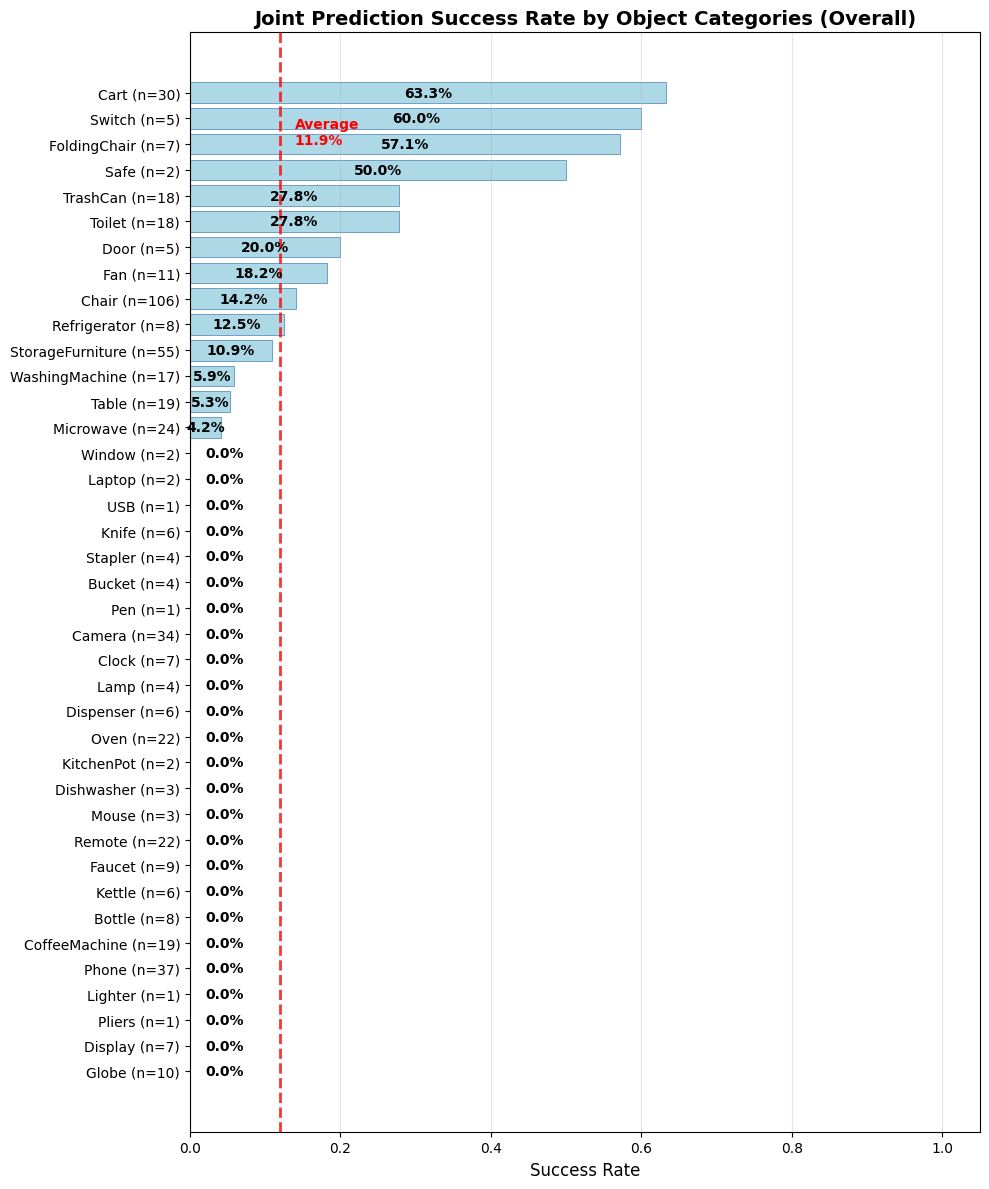

In [26]:
joint_results = analyze_joint_pred_by_type(results)

fig_joint = plot_joint_prediction_results(joint_results, save_path="/home/link/DreMa/third_party/articulate-anything/eval/joint_prediction_success_rates_generated.png")
plt.show()

In [27]:
# # Compute joint prediction results with generated naming convention
# joint_diffs = compute_joint_pred_result(
#     result_dir, 
#     strategy=strategy, 
#     dataset_dir=dataset_dir, 
#     use_result_dir=False,
#     naming_convention=naming_convention
# )
# joint_results = analyze_joint_pred_by_type(joint_diffs)

# fig_joint = plot_joint_prediction_results(joint_results, save_path="/home/link/DreMa/third_party/articulate-anything/eval/joint_prediction_success_rates_generated.png")
# plt.show()

In [28]:
analyze_failure_types(results, by_category=True)


Failure Analysis by Category
Failure Types:
- success: Joint prediction succeeded
- no_ground_truth: Could not load ground truth joints
- joint_not_in_gt: Joint not found in ground truth
- no_predicted_joints: Could not find predicted joint files
- joint_name_mismatch: Could not match joint names
- joint_diff_computation_failed: Joint comparison failed
- joint_type/joint_axis/joint_origin/joint_limit: Specific joint prediction errors
- vlm_failure: VLM wrote incompilable code (legacy)
- no_valid_result: Other unclassified failures (legacy)


Chair:
------
  joint_axis                11     (10.4%)
  joint_missing             43     (40.6%)
  joint_origin              28     (26.4%)
  joint_type                9      (8.5%)
  success                   15     (14.2%)

Globe:
------
  joint_axis                8      (80.0%)
  joint_missing             2      (20.0%)

Table:
------
  joint_axis                5      (26.3%)
  joint_missing             4      (21.1%)
  joint_origin       

Attempting to save pie chart to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated.png
Pie chart saved successfully to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated.png
Verified: File exists at /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated.png


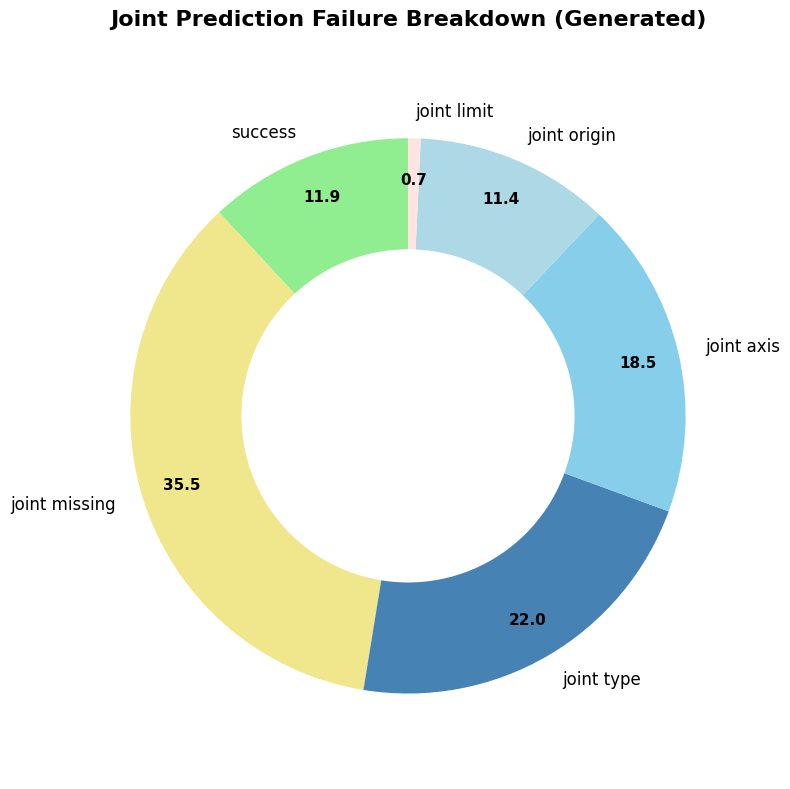

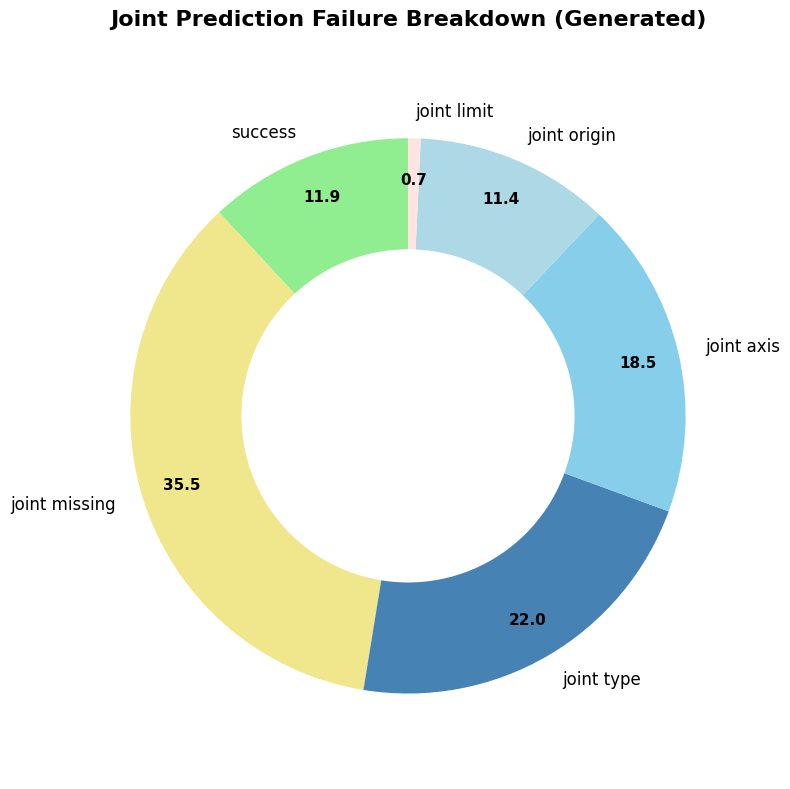

In [29]:
plot_failure_breakdown_pie(results, 
                          title="Joint Prediction Failure Breakdown (Generated)",
                          save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated.png")

Attempting to save pie chart to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated_no_missing.png
Pie chart saved successfully to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated_no_missing.png
Verified: File exists at /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated_no_missing.png


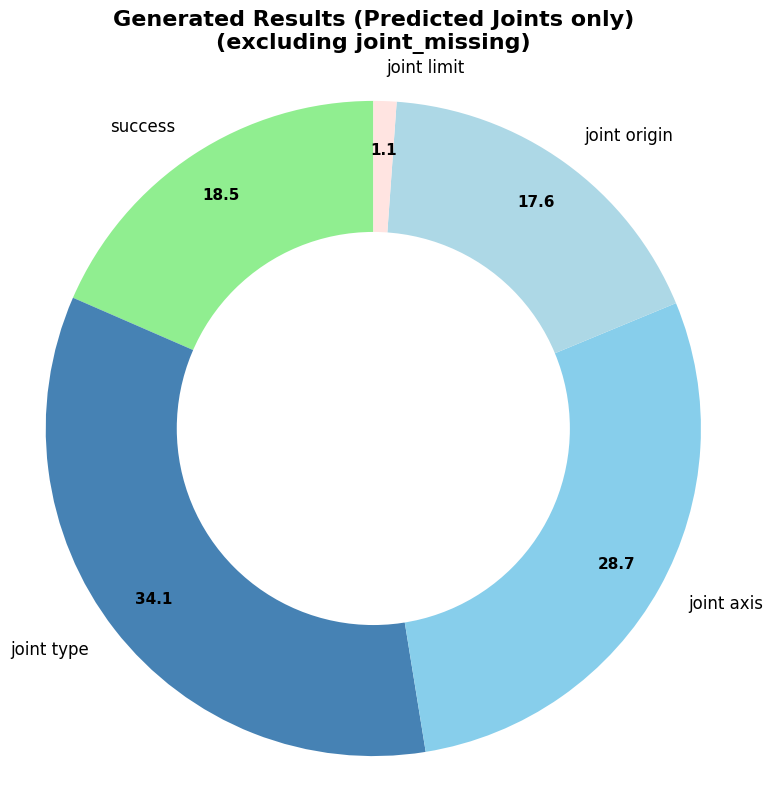

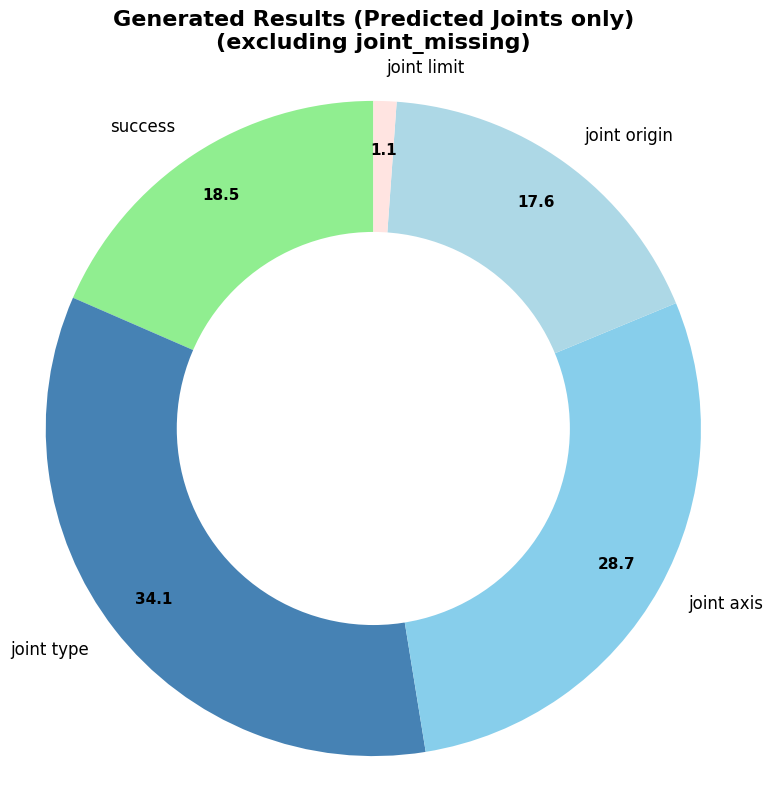

In [30]:
plot_failure_breakdown_pie(
    results, 
    "Generated Results (Predicted Joints only)",
    exclude_failures=['joint_missing'],
    save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_pie_generated_no_missing.png",
)

In [31]:
from articulate_anything.utils.metric import plot_failure_breakdown_sankey

# Sankey diagram (requires plotly for best results)
fig_sankey = plot_failure_breakdown_sankey(
    results,
    title="Joint Prediction Failure Flow",
    save_path="/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey_generated.html"  # Use .html for interactive
)

fig_sankey.write_image("/home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey_generated.png")


Interactive Sankey diagram saved to: /home/link/DreMa/third_party/articulate-anything/eval/failure_breakdown_sankey_generated.html


In [32]:
joint_results = analyze_joint_pred_by_type(results)
joint_latex = generate_joint_prediction_latex_table(joint_results)
print(joint_latex)

\begin{table}[h]
\centering
\begin{tabular}{llcc}
\toprule
Category & Joint Type & Count & Success Rate \\
\midrule
Cart & continuous & 29 & 65.5\% \\
 & total & 30 & 63.3\% \\
 & unknown & 1 & 0.0\% \\
Switch & revolute & 4 & 75.0\% \\
 & total & 5 & 60.0\% \\
 & continuous & 1 & 0.0\% \\
FoldingChair & revolute & 6 & 66.7\% \\
 & total & 7 & 57.1\% \\
 & unknown & 1 & 0.0\% \\
Safe & revolute & 1 & 100.0\% \\
 & total & 2 & 50.0\% \\
 & continuous & 1 & 0.0\% \\
Toilet & revolute & 8 & 62.5\% \\
 & total & 18 & 27.8\% \\
 & prismatic & 5 & 0.0\% \\
 & unknown & 5 & 0.0\% \\
TrashCan & revolute & 9 & 33.3\% \\
 & total & 18 & 27.8\% \\
 & continuous & 9 & 22.2\% \\
Door & revolute & 4 & 25.0\% \\
 & total & 5 & 20.0\% \\
 & unknown & 1 & 0.0\% \\
Fan & continuous & 9 & 22.2\% \\
 & total & 11 & 18.2\% \\
 & prismatic & 1 & 0.0\% \\
 & unknown & 1 & 0.0\% \\
Chair & continuous & 29 & 51.7\% \\
 & total & 106 & 14.2\% \\
 & unknown & 71 & 0.0\% \\
 & prismatic & 5 & 0.0\% \\
 & revolute

In [33]:
from articulate_anything.utils.metric import (
    compute_link_placement_result, analyze_link_placement_by_type, 
    compute_joint_pred_result, analyze_joint_pred_by_type,
    get_available_obj_ids, get_result_obj_dir, #debug_generated_results_structure
)
from articulate_anything.utils.partnet_utils import load_pickle, extract_joint_data_and_stats

result_dir = "results"
dataset_dir = "datasets/partnet-mobility-v0/dataset"
strategy = "gt"
naming_convention = "generated"

print("\n=== TESTING NEW JOINT PREDICTION EVALUATION ===")
joint_diffs = compute_joint_pred_result(
    result_dir, 
    strategy=strategy, 
    dataset_dir=dataset_dir, 
    use_result_dir=False,
    naming_convention=naming_convention
)
print(f"Joint diffs found: {len(joint_diffs)}")

if joint_diffs:
    # Check failure reasons
    failure_counts = {}
    for result in joint_diffs.values():
        reason = result['failure_reason']
        failure_counts[reason] = failure_counts.get(reason, 0) + 1
    print(f"Failure breakdown: {failure_counts}")
    
    # Show successful matches
    successful_matches = [(key, result) for key, result in joint_diffs.items() 
                         if result['failure_reason'] == 'success']
    print(f"Successful matches: {len(successful_matches)}")
    
    if successful_matches:
        print("Sample successful matches:")
        for i, (key, result) in enumerate(successful_matches[:3]):
            obj_id, joint_id, semantic_joint_id = key
            matched_name = result.get('matched_joint_name', 'N/A')
            print(f"  {semantic_joint_id} -> {matched_name}")


=== TESTING NEW JOINT PREDICTION EVALUATION ===
=== DEBUGGING HUNGARIAN JOINT EVALUATION ===
Available object IDs: ['2230', '100765', '100133', '19825', '102650', '103518', '102701', '23472', '103776', '4542']...

Debugging object 1: 2230
Evaluating joints for 2230 using position-based Hungarian matching
Debug: Loading predicted joints from results/generated/partnet_2230_single-view, naming=generated
Debug: Checking joint_actor_dir: results/generated/partnet_2230_single-view/joint_actor
Debug: joint_actor_dir exists: True
Debug: Contents: ['iter_0']
Debug: Found 1 iter directories: ['results/generated/partnet_2230_single-view/joint_actor/iter_0']
Debug: In results/generated/partnet_2230_single-view/joint_actor/iter_0, found 1 seed directories: ['results/generated/partnet_2230_single-view/joint_actor/iter_0/seed_0']
Debug: Checking joints file: results/generated/partnet_2230_single-view/joint_actor/iter_0/seed_0/robot_joints.json
Debug: File exists: True
Debug: Seed dir contents: ['vid

In [34]:
# from articulate_anything.utils.metric import compute_urdf_chamfer_analysis
# # Compute chamfer distances and get results by category
# chamfer_distances, chamfer_stats = compute_urdf_chamfer_analysis(
#     result_dir="results",
#     dataset_dir="datasets/partnet-mobility-v0/dataset", 
#     naming_convention="generated",
#     max_vertices_per_mesh=10000,  # Adjust based on your computational resources
#     debug=True  # Set to True for detailed debugging info
# )

# # # access individual results
# # print(f"Chamfer distance for object 12345: {chamfer_distances.get('3392', 'Not found')}")

# # Get just the mean chamfer distance for each category
# for category, stats in chamfer_stats.items():
#     print(f"{category}: {stats['mean']:.4f}")